Regressione lineare in Python

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

Carico il dataset

In [7]:
data=fetch_california_housing(as_frame=True) #carica direttamente il dataframe pandas
df=data.frame
print(f"Feature: {data.feature_names}")
print(df.head())
X=df[data.feature_names]
y=df["MedHouseVal"]

Feature: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
   MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127  ...     37.88    -122.23        4.526
1  8.3014      21.0  6.238137  ...     37.86    -122.22        3.585
2  7.2574      52.0  8.288136  ...     37.85    -122.24        3.521
3  5.6431      52.0  5.817352  ...     37.85    -122.25        3.413
4  3.8462      52.0  6.281853  ...     37.85    -122.25        3.422

[5 rows x 9 columns]


Creazione modello

In [8]:
model=LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
print (f"Intercetta: {model.intercept_}")
print(f"Feautre Coefficients:")
for name,coef in zip(data.feature_names,model.coef_):
    print(f"{name}: {coef:.4f}")


Intercetta: -36.94192020718434
Feautre Coefficients:
MedInc: 0.4367
HouseAge: 0.0094
AveRooms: -0.1073
AveBedrms: 0.6451
Population: -0.0000
AveOccup: -0.0038
Latitude: -0.4213
Longitude: -0.4345


I coefficienti vanno letti in base al segno ed al valore:
- segno positivo: aumenta il valore di label y (aumenta il prezzo)
- segno negativo: diminuisce il valore di label y (diminuisce il prezzo)
- valore grande: impatto forte
- valore piccolo: impatto debole
Nell'esempio impatto maggiore con la feature MedInc (0.4367) e AveBedrms (0.6451)
Impatto minimo con HouseAge (0.0094)
Lettura risultati:
MedInc (reddito medio): 0.4367, molto importante, una delle varibili principali, relazione    positiva quindi aumentando il reddito medio aumenta il valore della casa
HouseAge (eta della case): 0.0094, impatto minimo, quasi irrilevante
AveRooms (n. medio di stanze): -0.1073, relazione negativa (aumenta il numero di stanze diminuisce il prezzo delle case, sospetto). Controituitivo, potrebbe essere correlazione con altre varibili o multicollinearità
AveBedrms (camere da letto): 0.6451, molto importante, ma attenzione è legata a AveRooms, possibile problema
Population (popolazione): -0.0000, irrelevante, può essere ignorata
AveOccup (persone per casa): -0.0038
Latitude: -0.4213 posizione geografica molto importante
Longitude: -0.434 posizione geografica molto importante

In [11]:
y_pred=model.predict(X)

In [12]:
mae=np.mean(np.abs(y-y_pred))
print(f"MAE: {mae:.3f}")

MAE: 0.531


In [13]:
toll=0.5
good_pred=np.mean(np.abs(y-y_pred)<toll)
print(f"Percentuale Good Prediction: {good_pred*100:.2f}")

Percentuale Good Prediction: 58.82


Rappresentazione grafica

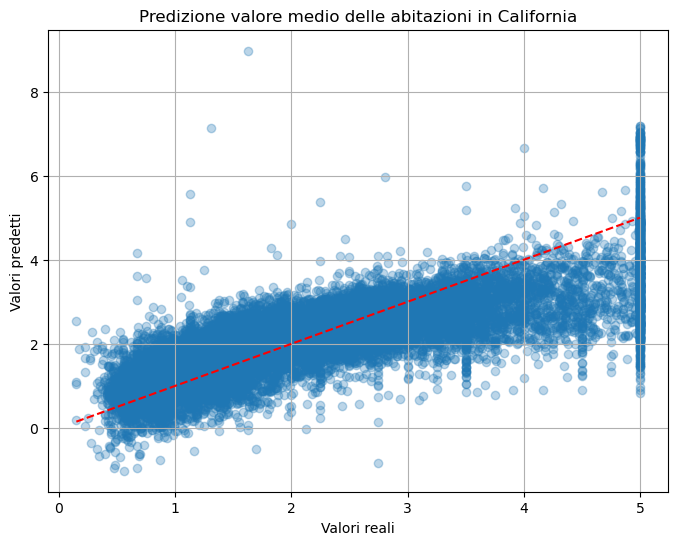

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y,y_pred,alpha=0.3)
plt.plot([y.min(),y.max()],[y.min(),y.max()],color="red",linestyle="--")
plt.xlabel("Valori reali")
plt.ylabel("Valori predetti")
plt.title("Predizione valore medio delle abitazioni in California")
plt.grid()
plt.show()

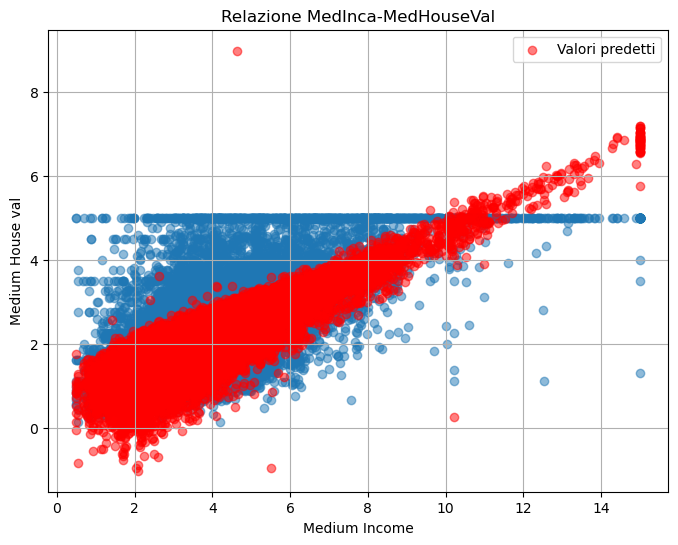

In [16]:
from cProfile import label


plt.figure(figsize=(8,6))
plt.scatter(df["MedInc"],df["MedHouseVal"],alpha=0.5)
plt.scatter(df["MedInc"],y_pred,alpha=0.5,color="red", label="Valori predetti")
plt.xlabel("Medium Income")
plt.ylabel("Medium House val")
plt.title("Relazione MedInca-MedHouseVal")
plt.legend()
plt.grid()
plt.show()

Il modello non ha generalizzato bene sui valori. In particolare verso la destra vedo che il modello ha dato un valore più alto rispetto a quello effettivo

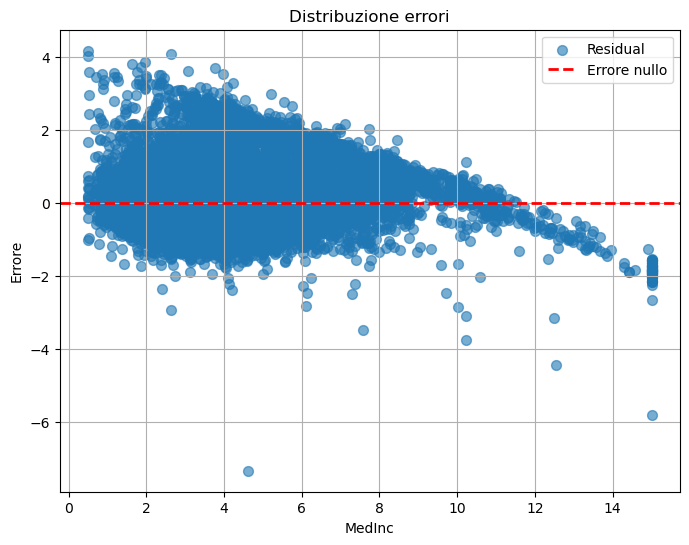

In [19]:
error=y.squeeze()-y_pred.ravel()
plt.figure(figsize=(8,6))
plt.scatter(df["MedInc"],error,alpha=0.6,s=50,label="Residual")
plt.axhline(y=0,color="red",linestyle="--",linewidth=2,label="Errore nullo")
plt.xlabel("MedInc")
plt.ylabel("Errore")
plt.title("Distribuzione errori")
plt.legend()
plt.grid()
plt.show()

ogni punto rappresenta il residuo, quidni quanto si discosta dalla predizone corretta (linea trateggiata rossa), i punti sopra o sotto non fittano bene. Infatti abbiamo una precisione di solo 60%